In [1]:
dataset = "mnist_red30_incremental"
root = "/Users/federicogiannini/Library/CloudStorage/OneDrive-PolitecnicodiMilano/SML_CL"

In [2]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def plot_kappa(perf, dataset):
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,5))
    for m in perf:
        ax.plot(perf[m], label=m, linestyle="-")
        ax.scatter(x=np.arange(0,len(perf[m])), y=perf[m], s=15)
    ax.set_xticks(np.arange(0,len(perf[m])))
    ax.set_xticklabels([f"c_{i}" for i in range(0,len(perf[m]))])
    ax.legend(loc="best")
    ax.set_title(dataset)
    ax.set_xlabel("Concepts", loc="right")
    ax.set_ylabel("Cohen's Kappa", loc="top")
    plt.tight_layout()
    plt.grid()
    plt.savefig(os.path.join(root, "performance", dataset, f"kappa_cl.png"), dpi=300)

In [4]:
with open(os.path.join(root, "performance", dataset, "cl_table.pkl"), "rb") as f:
    cl_table = pickle.load(f)
with open(os.path.join(root, "performance", dataset, "cl_table_cl.pkl"), "rb") as f:
    cl_table.update(pickle.load(f))

In [5]:
cumulative = {}
for m in cl_table:
    cumulative[m] = []
    for i in range(len(cl_table[m]["kappa"])):
        cumulative[m].append(np.mean(cl_table[m]["kappa"][i][:i+1]))

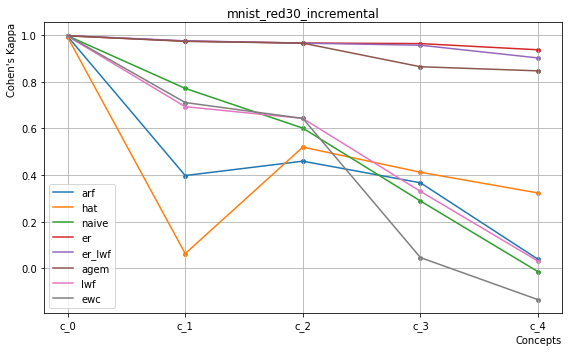

In [6]:
plot_kappa(cumulative, dataset)

In [7]:
cl_metrics = {}
for m in cl_table:
    n = len(cl_table[m]["kappa"])
    cl_metrics[m] = {
        "average": np.mean(cl_table[m]["kappa"][-1]),
        "a_metric": np.sum(
            [
                cl_table[m]["kappa"][i][j]
                for i in range(n)
                for j in range(i+1)
            ]
        )
        / (n * (n + 1) / 2),
        "bwt": np.sum(
            [
                (
                    cl_table[m]["kappa"][i][j]
                    - cl_table[m]["kappa"][j][j]
                )
                for i in range(1, n)
                for j in range(i)
            ]
        ) / (n * (n - 1) / 2),
    }
    
cl_metrics = pd.DataFrame(cl_metrics).T.reset_index().rename(columns={'index': 'model'}).sort_values("a_metric", ascending=False)

In [8]:
cl_metrics.to_excel(os.path.join(root, "performance", dataset, f"cl_metrics.xlsx"), index=False)
cl_metrics

,model,average,a_metric,bwt
3,er,0.937504,0.959379,-0.017813
4,er_lwf,0.902532,0.945981,-0.041381
5,agem,0.847167,0.902544,-0.103836
1,hat,0.323566,0.396470,-0.843002
6,lwf,0.031058,0.385927,-0.891687
2,naive,-0.014167,0.362141,-0.928408
0,arf,0.038948,0.322294,-0.909157
7,ewc,-0.134148,0.257680,-1.085204
